In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [2]:
### LOAD DATA

In [4]:
# load and combine experimet df

from src.loading import load_data

# -------------------- 3.0 m/s
df_3 = load_data("../data/target_trial_3_2025_11_7.parquet",  keep_col='training_status')
# ------------------- 2.0 m/s
df_2 = load_data("../data/target_trial_2.parquet")
# # drop every row from participant p030 due to corrupted data
df_2 = df_2[df_2['ppid'] != 'p030'].copy()

df_full = pd.concat([df_2, df_3], ignore_index=True)

In [4]:
### FORMAT DF

res: float64
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
41160    R30
41161    R30
41162    L60
41163    R30
41164    L60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
41160    R30
41161    R30
41162    L60
41163    R30
41164    L60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
['experiment', 'ppid', 'session_num', 'trial_num', 'block_num', 'trial_num_in_block', 'start_time', 'end_time', 'hand', 'target_hit', 'final_ball_state', 'type', 'target_position_x', 'target_position_y', 'target_position_z', 'target_width', 'launch_direction', 'before_launch_velocity_x', 'before_launch_velocity_z', 'before_launch_speed', 'before_launch_angle', 'current_force', 'water_inertia', 'water_speed_m_s', 'launch_angle', 'launch_Speed', 'slow_counter', 'ball_pos_x', 'ball

C:\Users\jacob\AppData\Local\Temp\ipykernel_9028\2846597812.py:50: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_labeled['set_order'] = df_labeled['set_order'].replace({
C:\Users\jacob\water_current_MA\src\add_phases.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['phase_target_trial_num'] = df.groupby(['ppid_full', 'phase', 'target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\add_cycles.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

crossed_threshold
True     39108
False      397
Name: count, dtype: int64
count                                                 39505
unique                                                39505
top       0.000000_0.013353_0.026616_0.052881_0.065885_0...
freq                                                      1
Name: ball_pos_z, dtype: object


C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


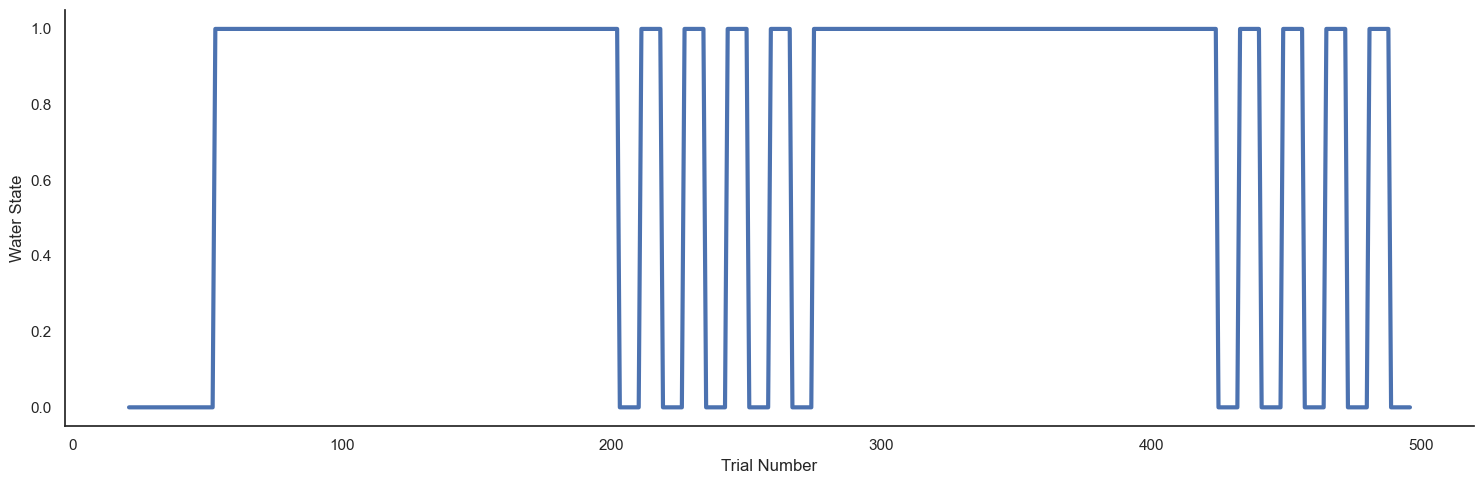

In [6]:

# add new variables

df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 

# convert key columns to cm:
from src.convert_to_cm import convert_to_cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes)

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 
# one-dimensional errors - in cm
df_labeled['lateral_error_x_cm'] = (df_labeled['min_pos_from_target_x'] - df_labeled['target_position_x']) * 100 # convert to cm
df_labeled['depth_error_z_cm'] = (df_labeled['min_pos_from_target_z'] - df_labeled['target_position_z']) * 100



# order targets

# adjust target label
target_mapping = {
    "p0.6": "R60",
    "p0.3": "R30",
    "neg0.3": "L30",
    "neg0.6": "L60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy()

from src.features import order_targets
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())

print(df_labeled.columns.to_list())
df_labeled['signed_euclidean_cm'] = df_labeled['ball_dist_to_center_cm'] * np.sign(df_labeled['lateral_error_x_cm'])



df_labeled['set_order'] = df_labeled['set_order'].replace({
    '1': '63_36',
    '2': '36_63'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()


# add temporal phase label categorical varible
from src.add_phases import label_phases, df_add_phases
phases = label_phases() 

df_labeled = df_add_phases(df_labeled, phase_array=phases).copy()


from src.add_cycles import add_cycles
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       ppid_col='ppid_full',
                       target_col='target_x_label',
                       ).copy()

# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())
print(df_nf['ball_pos_z'].describe())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')


from src.plotting import plot_trial_schedule
# trial schedule plot
g = plot_trial_schedule(df_small_filt, context='poster', font_scale=3, y_col='water_speed_binary')


In [6]:
df_small_filt.columns

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_deviation', 'launch_Speed', 'ball_dist_to_center_cm',
       'signed_euclidean_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90'],
      dtype='object')

In [7]:
### APPLY PCA

C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data.groupby(group_cols)
C:\Users\jacob\water_current_MA\src\PCA.py:99: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(


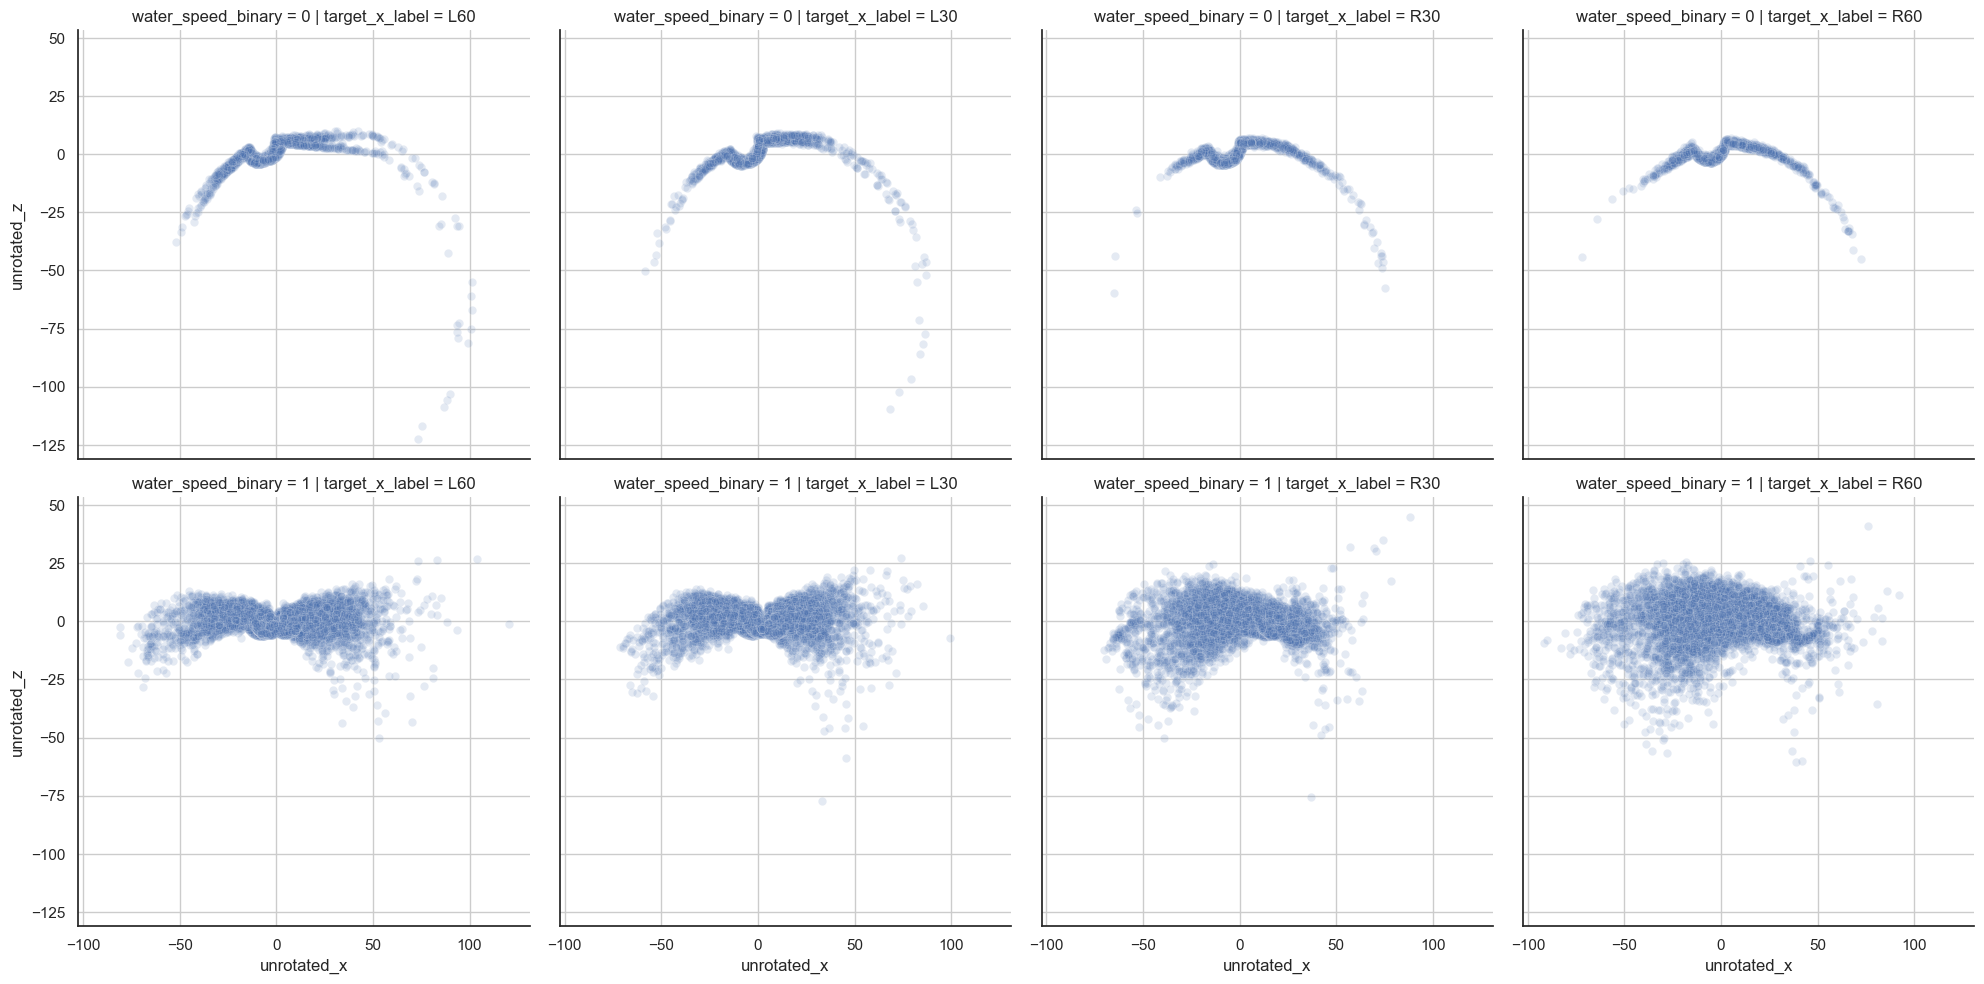

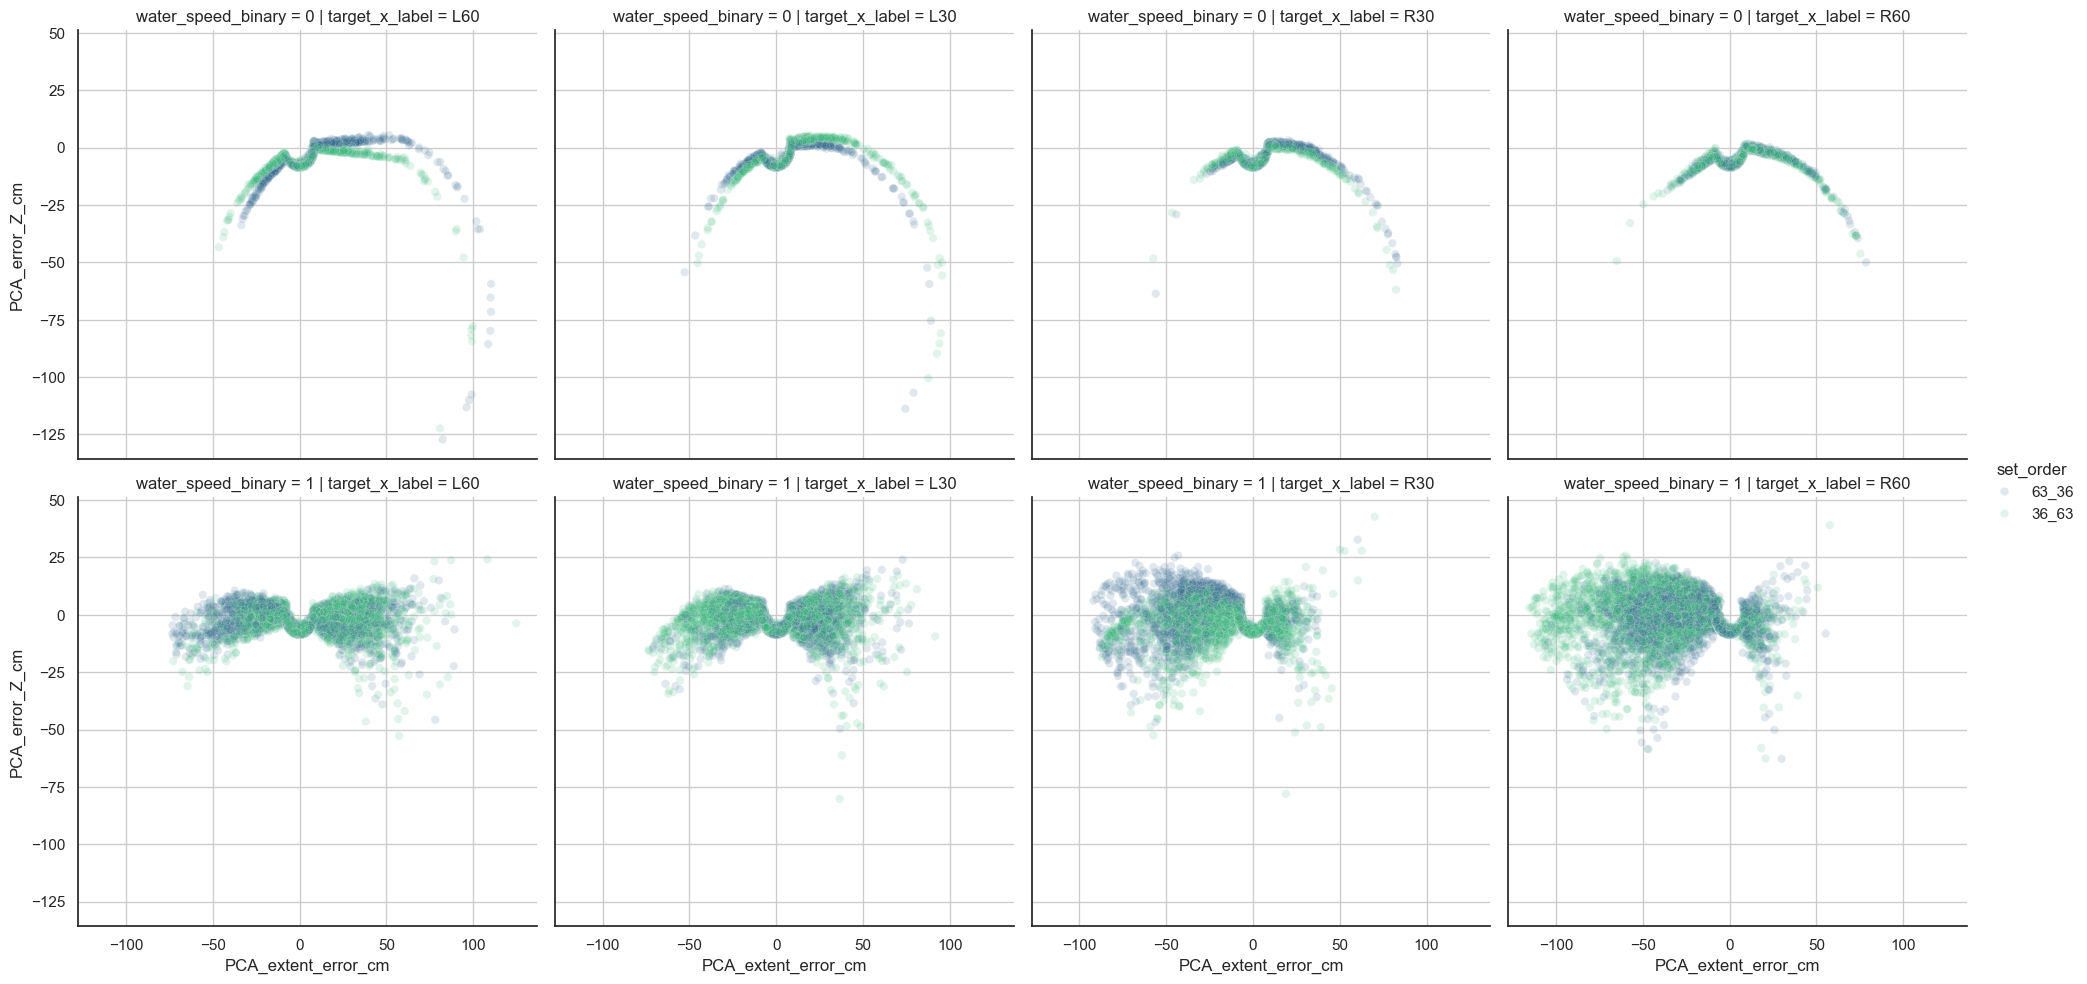

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_deviation', 'launch_Speed', 'ball_dist_to_center_cm',
       'signed_euclidean_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_extent_error_cm', 'PCA_error_Z_cm'],
      dtype='object')


,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_trial_num,phase_target_trial_num,...,centered_x,centered_z,unrotated_x,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_extent_error_cm,PCA_error_Z_cm
0,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,21,baseline,1,1,...,-8.422014,0.849144,-7.821262,-3.237162,-2.979414,7.283544,-6.071253,5.006676,-1.750010,-8.243838
1,projectile_experiment,p000_neg2,-2.0,L30,-30.0,140.0,22,baseline,2,1,...,9.450194,4.763292,9.260686,5.121993,-5.684806,4.519692,-5.853857,4.298488,15.114543,0.823505
2,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,23,baseline,3,1,...,-3.291001,-0.622905,-2.759994,-1.897666,-6.701501,7.220195,-9.044805,3.902927,6.284811,-5.800593
3,projectile_experiment,p000_neg2,-2.0,L60,-60.0,140.0,24,baseline,4,1,...,-6.100778,-2.752574,-5.920209,-3.122064,-8.935278,5.019826,-9.226709,4.461580,3.306500,-7.583644
4,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,25,baseline,5,2,...,0.636586,0.188844,0.471448,0.467591,-2.979414,7.283544,-6.071253,5.006676,6.542700,-4.539085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39103,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,492,washout_2,68,34,...,-18.245816,8.402305,-20.037318,1.419301,-5.212916,6.560305,-7.193396,4.297341,-12.843922,-2.878040
39104,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,493,washout_2,69,35,...,-1.522216,1.354205,-1.902303,0.729558,-5.212916,6.560305,-7.193396,4.297341,5.291093,-3.567783
39105,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,L60,-60.0,140.0,494,washout_2,70,35,...,1.604181,1.611923,1.744044,1.459453,-5.964219,4.917723,-5.492578,5.439439,7.236622,-3.979986
39106,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,495,washout_2,71,36,...,-12.965716,6.017105,-14.255134,1.051908,-5.212916,6.560305,-7.193396,4.297341,-7.061737,-3.245434


In [8]:
from src.PCA import compute_PCA_summary

features = ['min_pos_from_target_x_cm', 'min_pos_from_target_z_cm']
target_x_col = 'target_position_x_cm'
target_z_col = 'target_position_z_cm'


PCA_table = compute_PCA_summary(df_small_filt,
            features = features,
            group_cols = ['water_speed_m_s','set_order','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()

group_cols = ['water_speed_m_s','set_order','target_position_x_cm']
new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col=target_x_col,
                  target_z_col=target_z_col,
                  features = features,
                  group_cols = ['water_speed_m_s','set_order','target_position_x_cm'],
                  water_col = 'water_speed_m_s',
                  show_plots = True
                 )
print(PCA_error_df.columns)
PCA_error_df




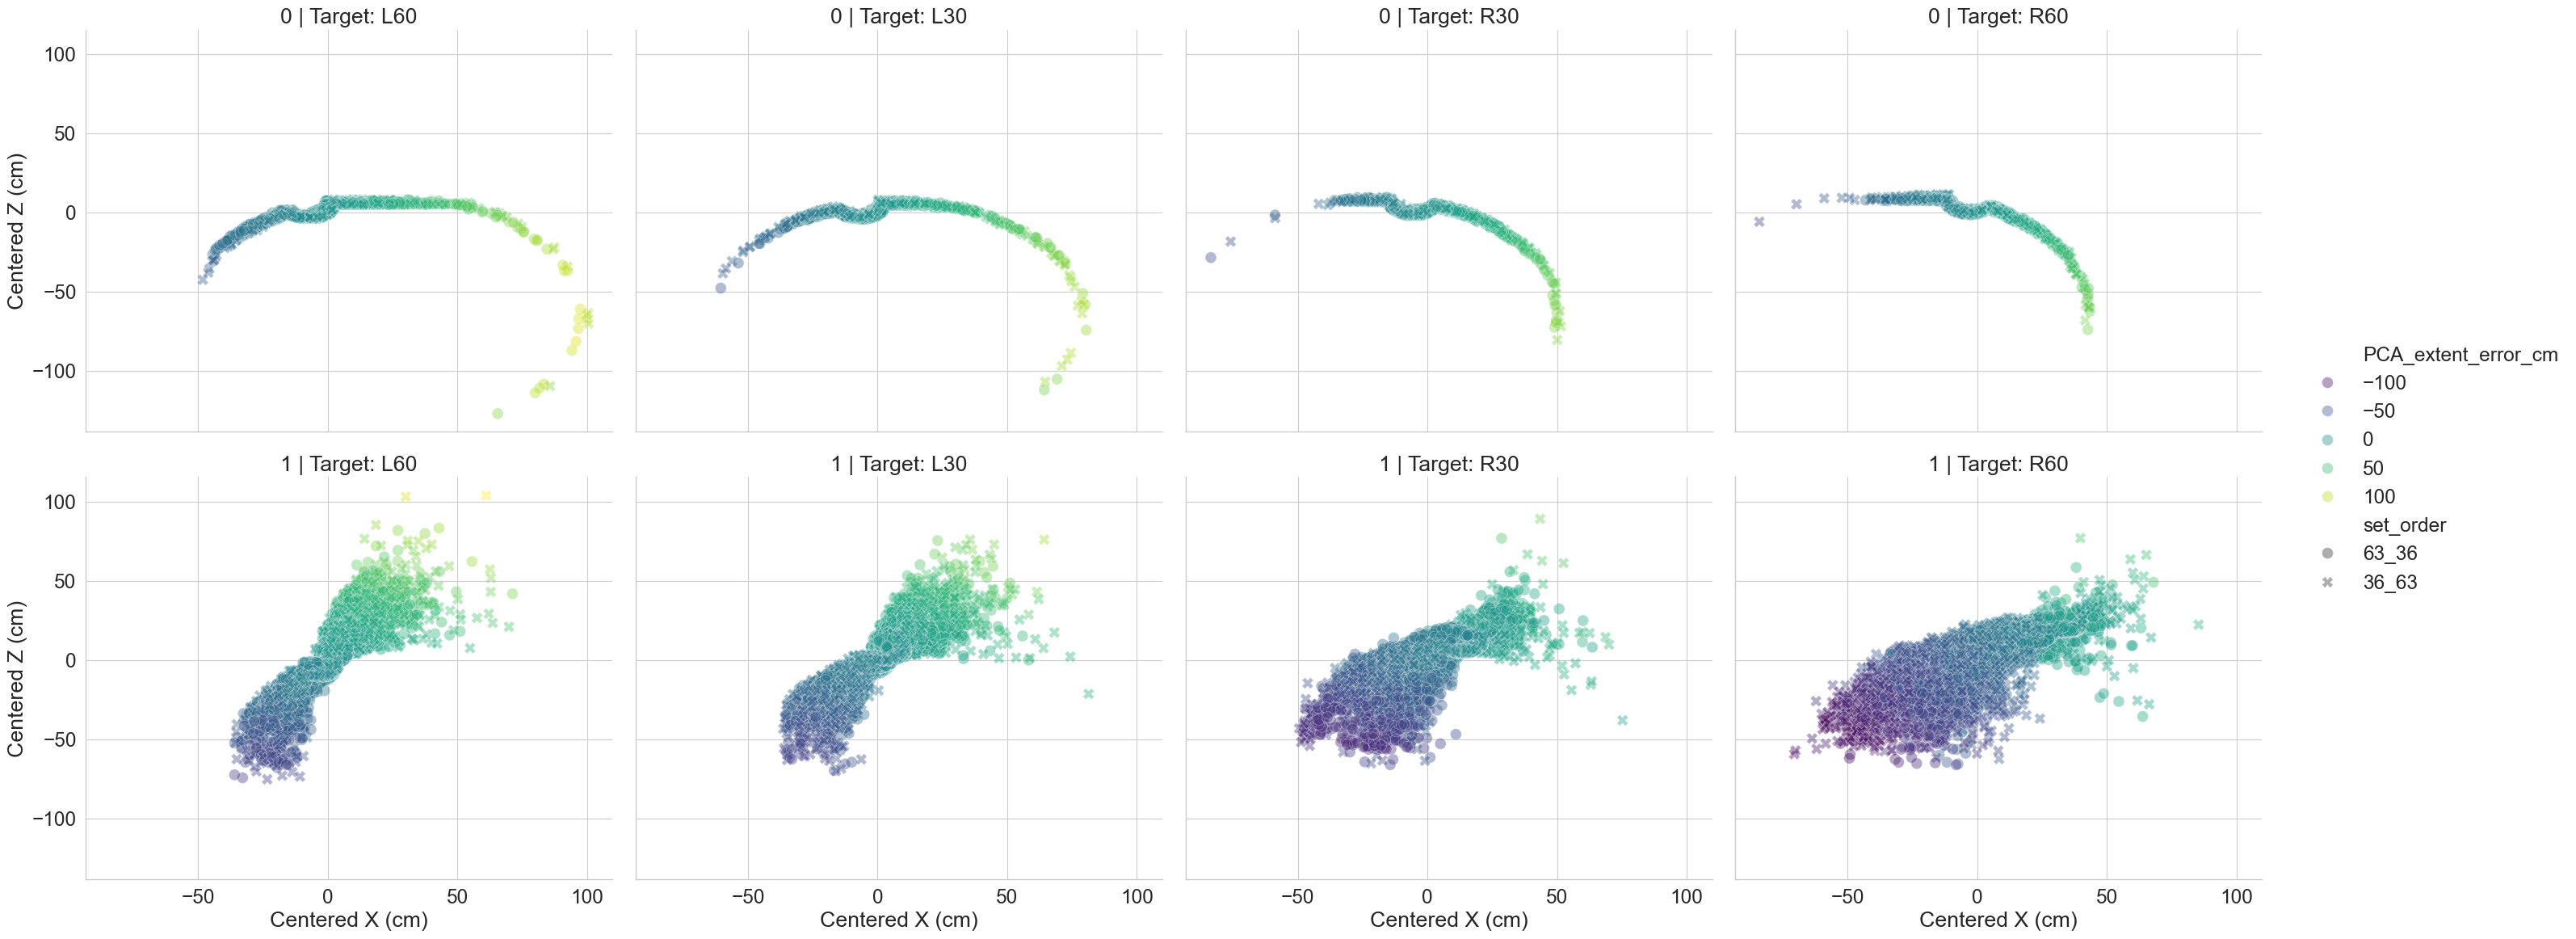

In [9]:

# Visualization of extent error
sns.set_context("paper", font_scale=2.0) 
sns.set_style("whitegrid")

# relplot
g = sns.relplot(
    data=PCA_error_df, 
    x='centered_x', 
    y='centered_z',
    hue='PCA_extent_error_cm', 
    style='set_order',
    col='target_x_label',  
    row='water_speed_binary',
    palette='viridis',            
    alpha=0.4,
    kind='scatter',
    height=6,     
    aspect=1.2,   
    s=100,        
    edgecolor='w',
    linewidth=0.5
)

# 3. Refine Facet Titles and Labels
g.set_titles(row_template="{row_name}", col_template="Target: {col_name}")
g.set_axis_labels("Centered X (cm)", "Centered Z (cm)")

# 4. Tighten layout and clarify legend
g.tight_layout()

plt.show()

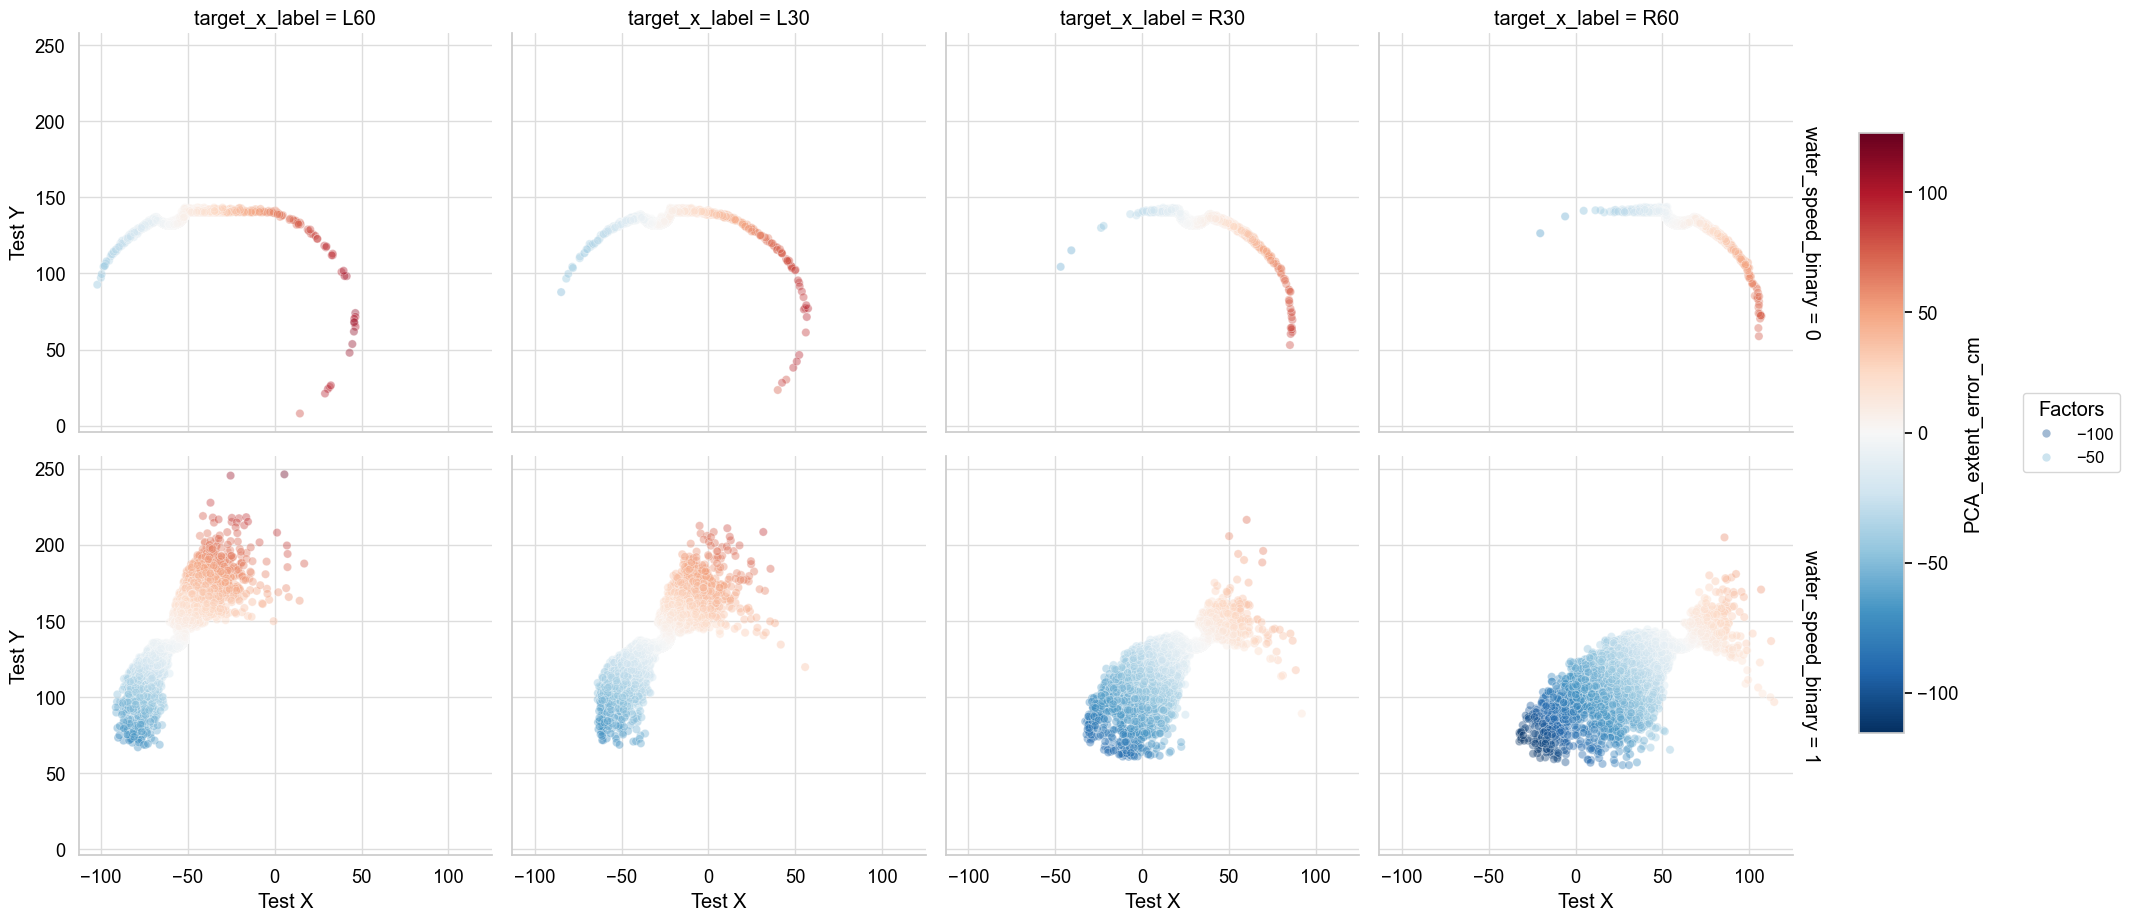

In [10]:
from src.plotting import plot_heatmap

plot_heatmap(PCA_error_df,
                     x_col = 'min_pos_from_target_x_cm',
                     y_col='min_pos_from_target_z_cm',
                     colour_col='PCA_extent_error_cm',
                     mode='correlation', 
                     facet_col='target_x_label',
                     facet_row='water_speed_binary',
                     dark=False,
                     x_col_title = 'Test X',
                     y_col_title = 'Test Y')

In [11]:
np.unique(PCA_error_df['pc_vector_1_angle'])

array([-28.2416476 , -27.61043295, -23.7930388 , -20.67468748,
        -8.12138903,  -3.52110027,  -2.19653005,   5.21462835,
        26.02040266,  30.47981931,  34.22013336,  36.94992657,
        38.33366474,  41.49705978,  44.38860334,  52.16600439,
        52.75415514,  53.27751389,  53.81944945,  53.95321782,
        59.25975665,  59.99368174,  62.05382874,  64.90146965])

In [12]:
# 1. Generate strictly 8 PCA models (4 targets x 2 contexts)
group_cols_8_way = ['water_speed_binary', 'target_position_x_cm']

tmp= PCA_table = compute_PCA_summary(
    df_small_filt,
    features=features,
    group_cols=group_cols_8_way,
    water_col='water_speed_m_s',
    n_components=2
)

# 2. Print the 8 angles
print(tmp[group_cols_8_way + ['pc_vector_1_angle']])

   water_speed_binary  target_position_x_cm  pc_vector_1_angle
0                   0                 -60.0           0.656367
1                   0                 -30.0          -5.779064
2                   0                  30.0         -22.239128
3                   0                  60.0         -27.872954
4                   1                 -60.0          61.685831
5                   1                 -30.0          53.243388
6                   1                  30.0          43.616088
7                   1                  60.0          37.305211


In [13]:
tmp

,water_speed_binary,target_position_x_cm,pc_vector_1_angle,pc_vector_1_pca_center_x,pc_vector_1_pca_center_z,pc_vector_1_c_X,pc_vector_1_c_Z,pc_vector_1_variance_ratio,pc_vector_2_angle,pc_vector_2_pca_center_x,pc_vector_2_pca_center_z,pc_vector_2_c_X,pc_vector_2_c_Z,pc_vector_2_variance_ratio
0,0,-60.0,0.656367,-52.602712,135.033029,0.999934,0.011456,0.822436,90.656367,-52.602712,135.033029,-0.011456,0.999934,0.177564
1,0,-30.0,-5.779064,-23.206902,135.266756,0.994918,-0.100693,0.828435,84.220936,-23.206902,135.266756,0.100693,0.994918,0.171565
2,0,30.0,-22.239128,35.929928,133.121844,0.925612,-0.378473,0.892974,67.760872,35.929928,133.121844,0.378473,0.925612,0.107026
3,0,60.0,-27.872954,63.374569,132.442219,0.883986,-0.467513,0.925210,62.127046,63.374569,132.442219,0.467513,0.883986,0.074790
4,1,-60.0,61.685831,-56.165603,141.430545,0.474306,0.880360,0.950049,-28.314169,-56.165603,141.430545,0.880360,-0.474306,0.049951
5,1,-30.0,53.243388,-28.536138,137.471651,0.598417,0.801185,0.932058,-36.756612,-28.536138,137.471651,0.801185,-0.598417,0.067942
6,1,30.0,43.616088,18.728249,126.735398,0.723978,0.689823,0.877909,133.616088,18.728249,126.735398,-0.689823,0.723978,0.122091
7,1,60.0,37.305211,39.924968,123.567532,0.795418,0.606061,0.886511,127.305211,39.924968,123.567532,-0.606061,0.795418,0.113489


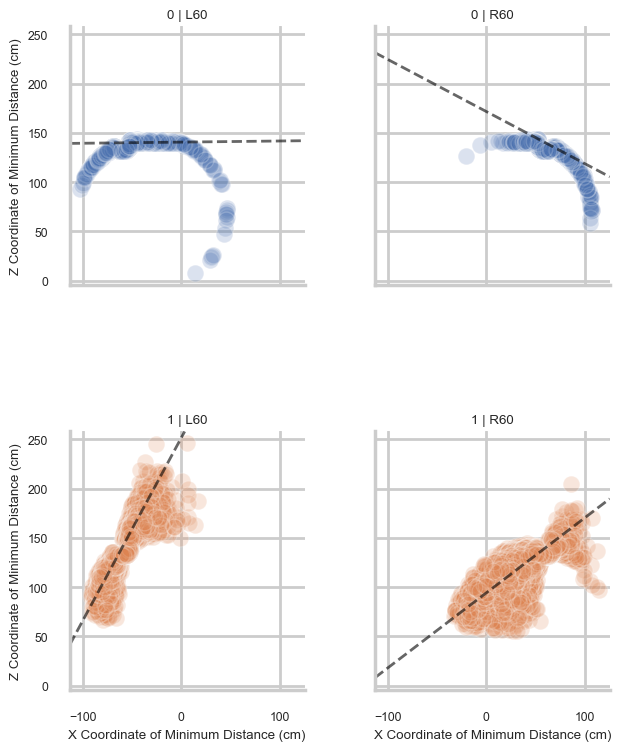

In [14]:
from src.plotting import plot_min_x_z

#slope_array=[[0.656367, -5.779064, -22.239128, -27.872954],
 #                         [61.685831, 53.243388, 43.616088, 37.305211]],

plot_min_x_z(PCA_error_df,
             c_col='target_x_label',
             r_col='water_speed_binary',
             slope_array=[[0.656367, -27.872954],
                          [61.685831, 37.305211]],
             target_x_array=[-60, 60], 
             show_slopes=True,
             x_col_title = 'X Coordinate of Minimum Distance (cm)',
             y_col_title = 'Z Coordinate of Minimum Distance (cm)',
             context='poster'
            )

In [15]:
### remove outliers

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

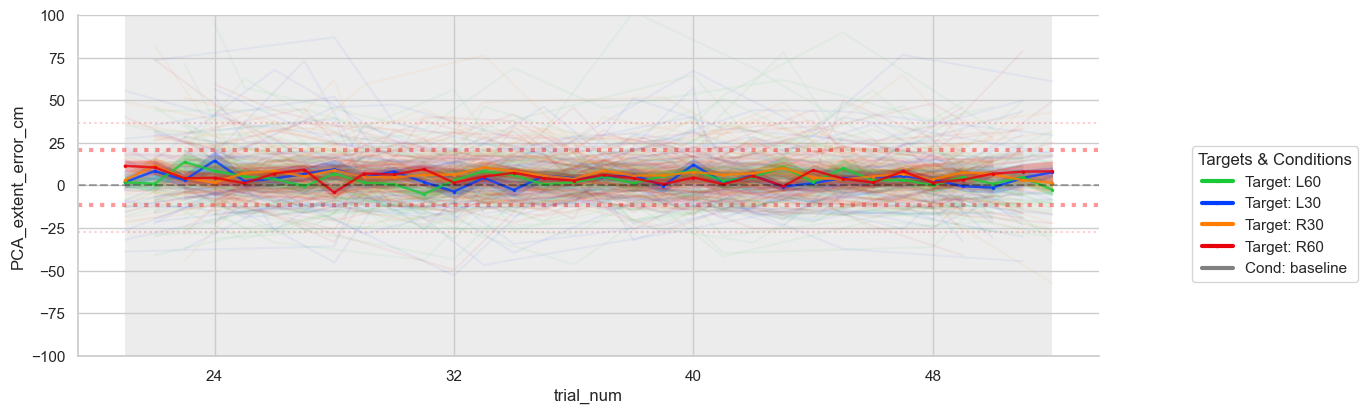

In [10]:
from src.plotting import plot_all_trials

df_baseline = PCA_error_df[PCA_error_df['phase'] == 'baseline']

plot_all_trials(df_baseline, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_extent_error_cm', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                    show_sd_line=True

                    )




--- Baseline Trial Outlier Removal (PCA_extent_error_cm) ---
Baseline Mean: 4.8385, SD: 16.0568
SD Threshold: 2.0 (32.1135 units)
Trials removed: 143 / 2654 total baseline trials
PCA_error_df (39108, 44)
clean_df (38965, 44)


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

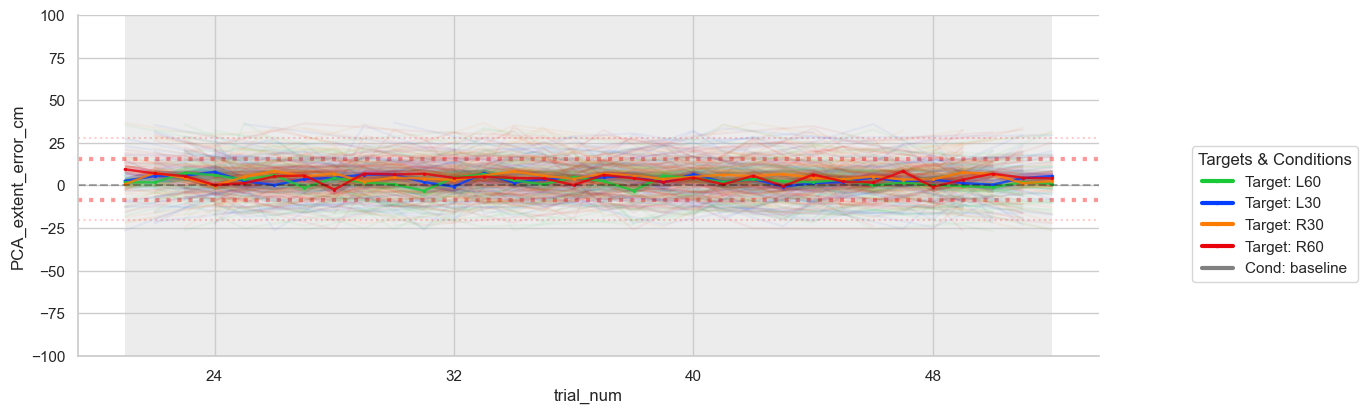

In [13]:
from src.cleaning import remove_baseline_outlier_trials_threshold_sd

# tag baseline outlier ppid
clean_df = remove_baseline_outlier_trials_threshold_sd(PCA_error_df,
                            y_col='PCA_extent_error_cm',
                            trial_col='trial_num'
                               )

print('PCA_error_df', PCA_error_df.shape)
print('clean_df', clean_df.shape)

from src.plotting import plot_all_trials

df_baseline_clean = clean_df[clean_df['phase'] == 'baseline']

plot_all_trials(df_baseline_clean, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_extent_error_cm', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                     show_sd_line=True
                    )




In [18]:
clean_df.columns

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_deviation', 'launch_Speed', 'ball_dist_to_center_cm',
       'signed_euclidean_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_extent_error_cm', 'PCA_error_Z_cm'],
      dtype='object')

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

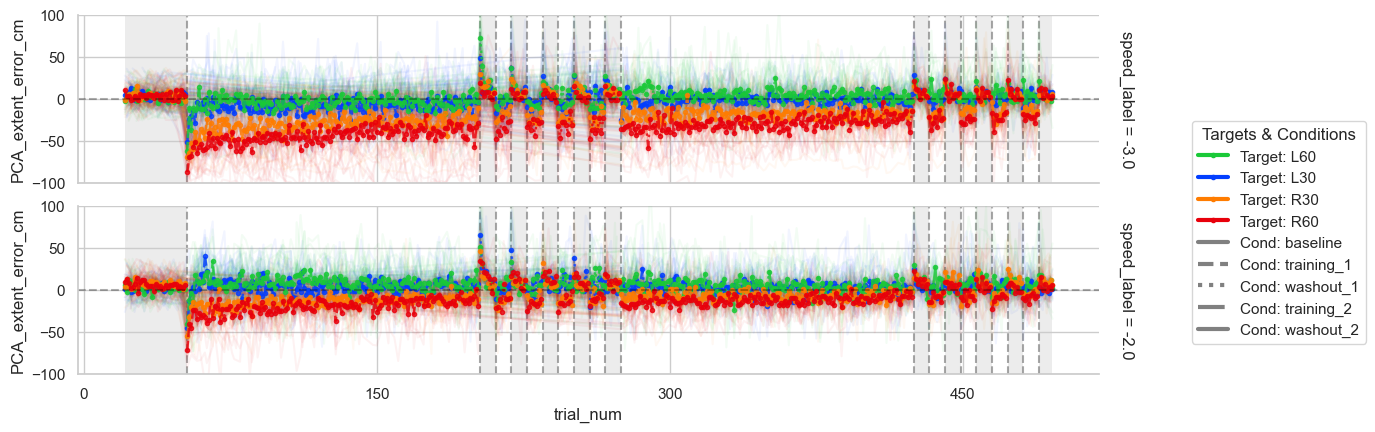

In [15]:
from src.plotting import plot_all_trials


plot_all_trials(clean_df, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_extent_error_cm', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=3,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )




In [19]:
from src.baseline_correct import baseline_correct

df_bc = baseline_correct(data = clean_df,
                phase_col = 'phase',
                baseline_string='baseline',
                y_col='lateral_error_x_cm',
                PCA_col='PCA_extent_error_cm'# lateral_error_x_cm, PCA_error_X_cm
                ) 
df_bc




# Extract and join unique experiment strings
exp_tags = "_".join(df_bc['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_bc['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\dual_generalization\\{file_name}"

df_bc.to_csv(file_path, index=False)
print(f"Saved: {file_path}")



from src.early_late_exposure import early_late_phase

early_late_phase_df = early_late_phase(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 4
                ).copy()

# Extract and join unique experiment strings
unique_exps = df_bc['experiment'].unique().astype(str)
exp_tags = "_".join(unique_exps[:2]) 
if len(unique_exps) > 2:
    exp_tags += "_etc"
    
# Extract unique water speeds, rounded to prevent floating point noise
speeds = early_late_phase_df['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"early_late_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\dual_generalization\\{file_name}"

early_late_phase_df.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

C:\Users\jacob\water_current_MA\src\baseline_correct.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_baseline = df_filtered.groupby(grouping_vars)[[y_col, PCA_col]].agg(['mean', 'median'])
C:\Users\jacob\water_current_MA\src\baseline_correct.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  assert np.isclose(df_merged[check_mask].groupby(grouping_vars)[f"{y_col}_median_bc"].median(), 0, atol=1e-8).all()
C:\Users\jacob\water_current_MA\src\baseline_correct.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

Saved: ..\data\dual_generalization\PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0_0_0.csv
Saved: ..\data\dual_generalization\early_late_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv


C:\Users\jacob\water_current_MA\src\early_late_exposure.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_max = df.groupby(group_cols + [phase_col])[trial_col].transform('max')


In [21]:
### SAVE PCA OUPUT DF

In [22]:
df_bc

,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_trial_num,phase_target_trial_num,...,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_extent_error_cm,PCA_error_Z_cm,PCA_extent_error_cm_mean,PCA_extent_error_cm_median,PCA_extent_error_cm_mean_bc,PCA_extent_error_cm_median_bc
0,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,21,baseline,1,1,...,-2.979414,7.283544,-6.071253,5.006676,-1.750010,-8.243838,4.548843,4.258677,-6.298853,-6.008686
1,projectile_experiment,p000_neg2,-2.0,L30,-30.0,140.0,22,baseline,2,1,...,-5.684806,4.519692,-5.853857,4.298488,15.114543,0.823505,8.456296,15.114543,6.658247,0.000000
2,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,23,baseline,3,1,...,-6.701501,7.220195,-9.044805,3.902927,6.284811,-5.800593,7.767112,8.305907,-1.482300,-2.021096
3,projectile_experiment,p000_neg2,-2.0,L60,-60.0,140.0,24,baseline,4,1,...,-8.935278,5.019826,-9.226709,4.461580,3.306500,-7.583644,3.101246,3.306500,0.205253,0.000000
4,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,25,baseline,5,2,...,-2.979414,7.283544,-6.071253,5.006676,6.542700,-4.539085,4.548843,4.258677,1.993857,2.284024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38960,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,492,washout_2,68,34,...,-5.212916,6.560305,-7.193396,4.297341,-12.843922,-2.878040,3.369440,-6.713816,-16.213361,-6.130105
38961,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,493,washout_2,69,35,...,-5.212916,6.560305,-7.193396,4.297341,5.291093,-3.567783,3.369440,-6.713816,1.921653,12.004909
38962,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,L60,-60.0,140.0,494,washout_2,70,35,...,-5.964219,4.917723,-5.492578,5.439439,7.236622,-3.979986,-4.772351,-10.601427,12.008973,17.838049
38963,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,R30,30.0,140.0,495,washout_2,71,36,...,-5.212916,6.560305,-7.193396,4.297341,-7.061737,-3.245434,3.369440,-6.713816,-10.431177,-0.347921


In [23]:
### PLOTS

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

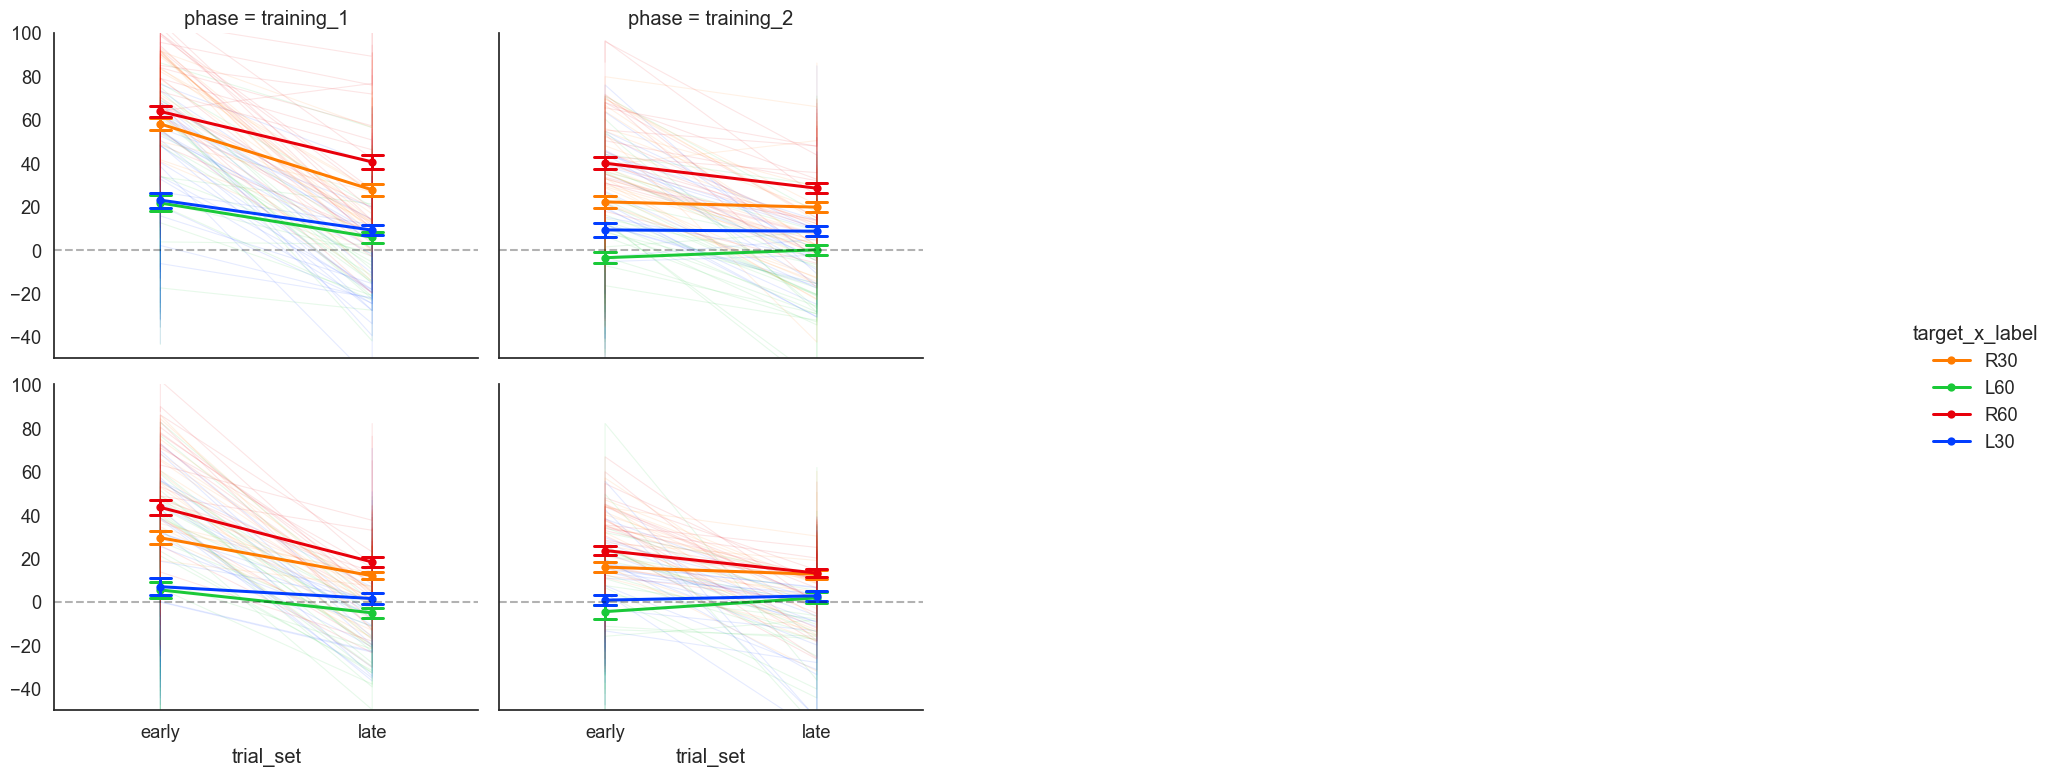

In [79]:
from src.plotting import plot_early_late_exposure

early_late_phase_df['flip_PCA_extent_error_cm_mean_bc'] = early_late_phase_df['PCA_extent_error_cm_mean_bc'] * -1.0

plot_early_late_exposure(early_late_phase_df,
                         x_col='trial_set',
                         y_col='flip_PCA_extent_error_cm_mean_bc',
                         ylim=(-50,100),
                         line_col='target_x_label',
                         cond_col='target_x_label', 
                         ppid_col='ppid_full',
                         facet_row='speed_label',
                         facet_col= 'phase',
                         show_zero_line=True
                        )


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

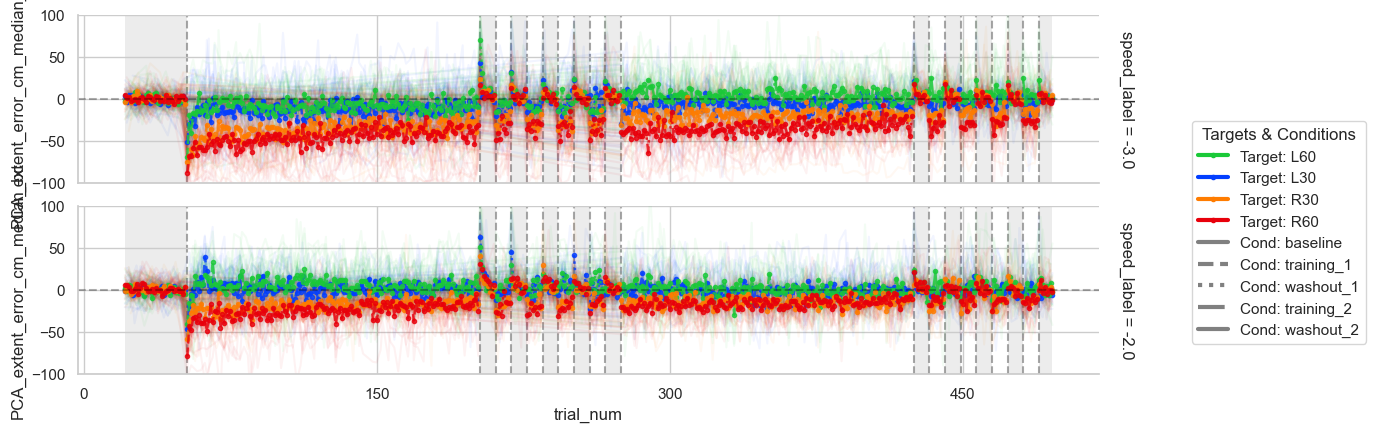

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

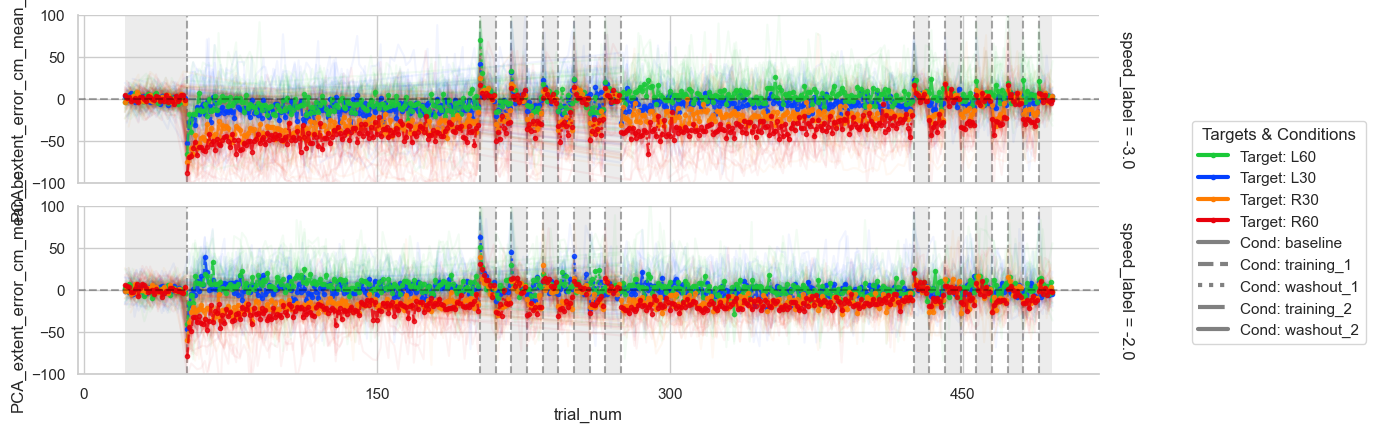

In [21]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_extent_error_cm_median_bc', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=3.0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_extent_error_cm_mean_bc', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     marker_size=3.0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )




In [ ]:
df_bc

In [ ]:
# WASHOUT

In [31]:
# filter and save baseline-washout data csv

from src.baseline_washout import retain_baseline_washout



df_baseline_washout = retain_baseline_washout(df_bc,
                           phase_col='phase',
                           experiment_type ='dual_generalization',
                           phases_to_keep = ['baseline','washout_1','washout_2'],
                           experiment_col = 'experiment',
                           water_col = 'water_speed_binary')
df_baseline_washout



Saved: ..\data\dual_generalization\baseline_washout_projectile_experiment _S1-projectile_experiment_etc_speed_0.csv


C:\Users\jacob\water_current_MA\src\baseline_washout.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  washout_data = washout_data.groupby(target_col).apply(
C:\Users\jacob\water_current_MA\src\baseline_washout.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  washout_data = washout_data.groupby(target_col).apply(


,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_trial_num,phase_target_trial_num,...,PCA_extent_error_cm,PCA_error_Z_cm,lateral_error_x_cm_mean,lateral_error_x_cm_median,PCA_extent_error_cm_mean,PCA_extent_error_cm_median,lateral_error_x_cm_mean_bc,lateral_error_x_cm_median_bc,PCA_extent_error_cm_mean_bc,PCA_extent_error_cm_median_bc
0,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,21,baseline,1,1,...,-1.750010,-8.243838,2.090063,0.72975,4.548843,4.258677,-7.532662,-6.17235,-6.298853,-6.008686
1,projectile_experiment,p000_neg2,-2.0,L30,-30.0,140.0,22,baseline,2,1,...,15.114543,0.823505,8.369714,15.13500,8.456296,15.114543,6.765286,0.00000,6.658247,0.000000
2,projectile_experiment,p000_neg2,-2.0,R30,30.0,140.0,23,baseline,3,1,...,6.284811,-5.800593,6.177050,6.68500,7.767112,8.305907,-2.766550,-3.27450,-1.482300,-2.021096
3,projectile_experiment,p000_neg2,-2.0,L60,-60.0,140.0,24,baseline,4,1,...,3.306500,-7.583644,2.806971,2.83450,3.101246,3.306500,0.027529,0.00000,0.205253,0.000000
4,projectile_experiment,p000_neg2,-2.0,R60,60.0,140.0,25,baseline,5,2,...,6.542700,-4.539085,2.090063,0.72975,4.548843,4.258677,1.525937,2.88625,1.993857,2.284024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2538,projectile_experiment,p008_neg2,-2.0,R60,60.0,140.0,425,washout_2,1,1,...,69.447501,-33.395908,11.326850,11.54680,13.631488,13.321235,34.050950,33.83100,55.816013,56.126266
2539,projectile_experiment,p011_neg2,-2.0,R60,60.0,140.0,203,washout_1,1,1,...,24.187789,-3.376284,5.164638,4.34540,7.979664,7.130477,14.703862,15.52310,16.208125,17.057312
2540,S1-projectile_experiment,p017_neg2,-2.0,R60,60.0,140.0,425,washout_2,1,1,...,18.772261,-0.501079,-7.545025,-7.71835,-5.114487,-6.172956,23.845525,24.01885,23.886748,24.945217
2541,S2-projectile_experiment,p021_neg2,-2.0,R60,60.0,140.0,203,washout_1,1,1,...,12.949429,0.196485,5.916925,8.54070,8.260869,9.678432,5.648875,3.02510,4.688560,3.270998


In [27]:
df_baseline_washout.columns

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_deviation', 'launch_Speed', 'ball_dist_to_center_cm',
       'signed_euclidean_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_extent_error_cm', 'PCA_error_Z_cm',
       'abs_PCA_extent_error_cm', 'PCA_extent_error_cm_mean',
    

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

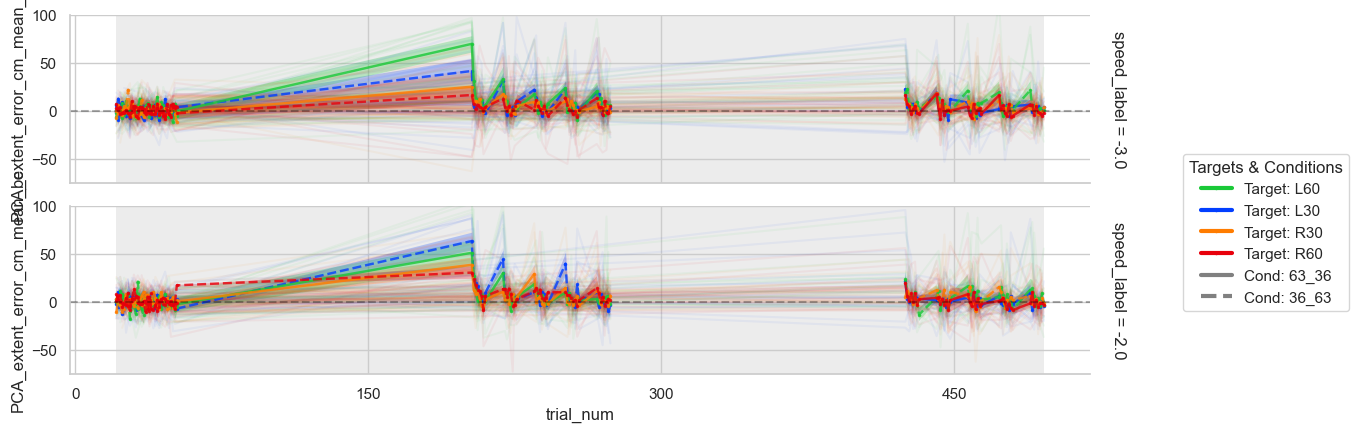

In [25]:


# plot across washout
from src.plotting import plot_all_trials
plot_all_trials(df_baseline_washout, 
                     col_col = None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_extent_error_cm_mean_bc', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-75,100),
                     show_zero_line=True
                    )

In [ ]:
### Generalization/savings plot:

In [55]:
np.unique(early_late_phase_df['phase'])

array(['training_1', 'training_2'], dtype=object)

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

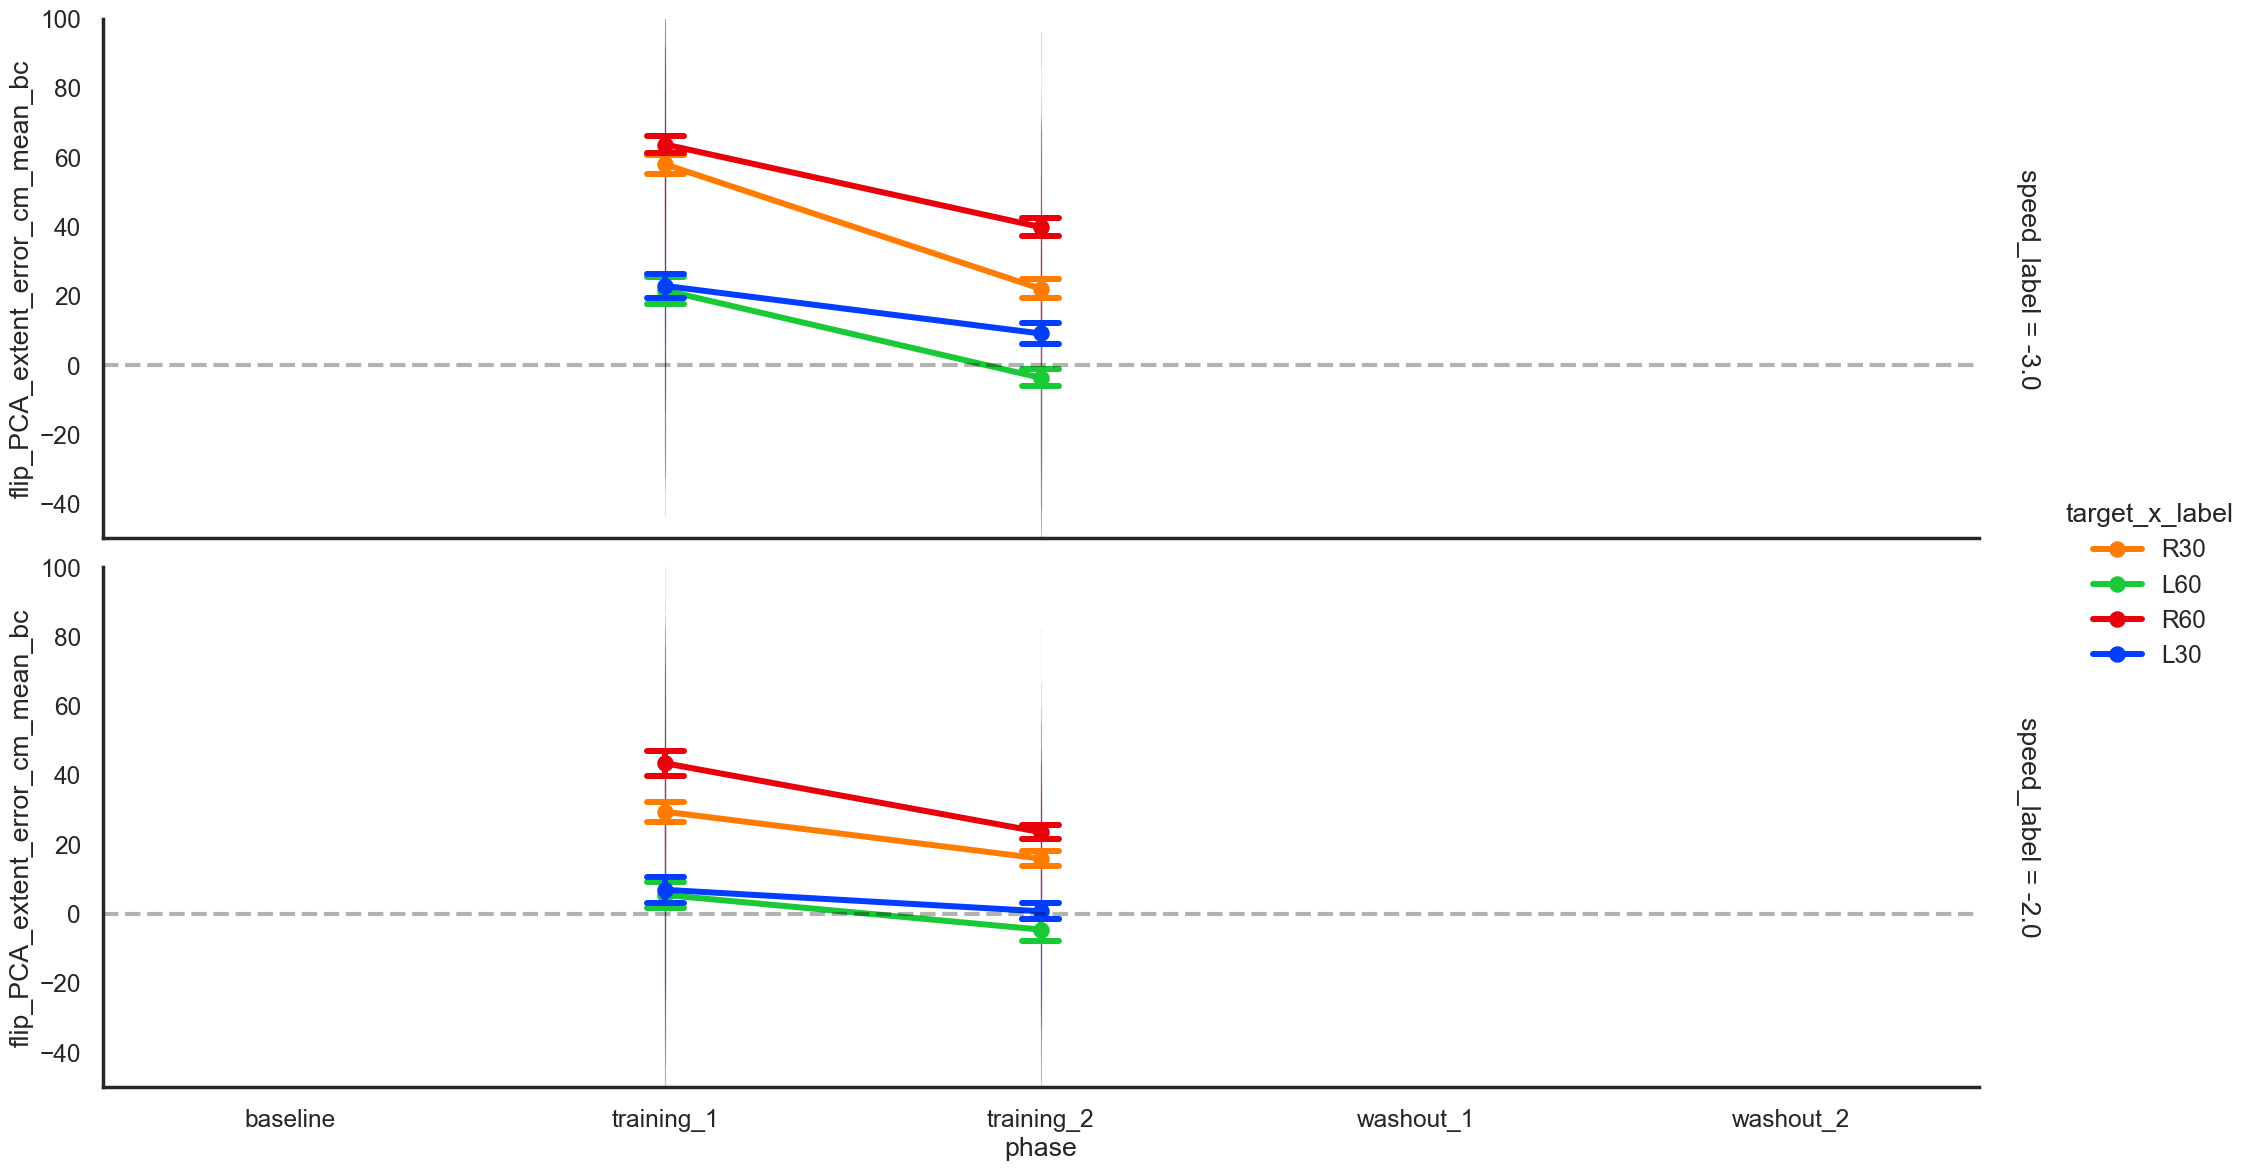

In [115]:
from src.plotting import plot_early_late_exposure

early_phase_df = early_late_phase_df[early_late_phase_df['trial_set'] == 'early']



plot_early_late_exposure(early_phase_df,
                         x_col='phase',
                         y_col='flip_PCA_extent_error_cm_mean_bc',
                         ylim=(-50,100),
                         line_col='target_x_label',
                         cond_col='target_x_label', 
                         ppid_col='ppid_full',
                         facet_row='speed_label',
                         facet_col= None,
                         show_zero_line=True,
                         font_scale = 0.8,
                         facet_height=6.00,
                         facet_aspect=3.50,
                         context='poster'
                        )


In [ ]:
# Bayesian Optimizer

In [5]:
import numpy as np
from skopt import gp_minimize

gp_minimize

In [7]:
res

          fun: -1.1219469956836408
            x: [-0.260256577411593]
    func_vals: [-8.697e-01 -9.936e-02 ... -8.709e-01 -1.100e+00]
      x_iters: [[-0.19534367640329764], [1.047944672000631], [-1.6229074505681291], [0.13145523933067604], [0.376706271879768], [1.5060047944814694], [-0.581831643534868], [0.3110618974402195], [0.2138796262485254], [-1.261443114245655], [-0.22619013190994441], [-0.13437886214372785], [-0.33309076419625017], [-2.0], [-0.24789452533358625], [2.0], [-0.8957599430005874], [-0.4050498971036465], [0.7933364757775303], [-0.19660032654968718], [-0.1849652930055954], [-0.2085133121242213], [-0.23111665173102103], [-0.23202693979172562], [-0.23956049562870052], [-0.24644267309235857], [-0.25449313080194846], [-0.2544412825944222], [-0.25260805645489715], [-0.2479523125451879], [-0.24407631375338013], [-0.2452610107766291], [-0.24645914979613726], [-0.24176746064905563], [-0.24157818284229737], [-0.24575356715939578], [-0.24249541441187428], [-0.2372722399375733